## Neural Network Project : Fashion MNIST Dataset Sorting

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
fashion_mnist=keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

60,000 images 28 x 28

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
x_train.dtype

dtype('uint8')

In [7]:
x_valid,x_trn= x_train[:5000]/255. , x_train[5000:]/255.
y_valid,y_trn= y_train[:5000], y_train[5000:]
x_test=x_test/255.

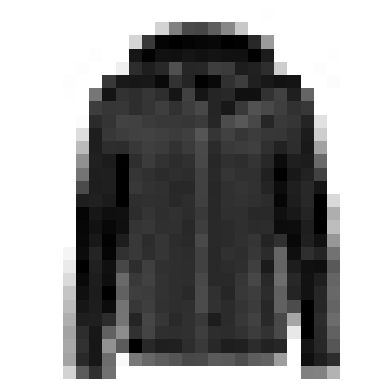

In [8]:
plt.imshow(x_trn[0],cmap='binary')

#cmap='binary':
# Uses black & white color mapping
# White → higher pixel value
# Black → lower pixel value
# cmap='binary':
# Uses black & white color mapping
# White → higher pixel value
# Black → lower pixel value


plt.axis('off')
plt.show()

In [9]:
y_trn

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

In [10]:
# x_trn[0] 28 * 28

In [11]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [12]:
print(y_train[0])

9


In [13]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [14]:
x_valid.shape

(5000, 28, 28)

In [15]:
x_test.shape

(10000, 28, 28)

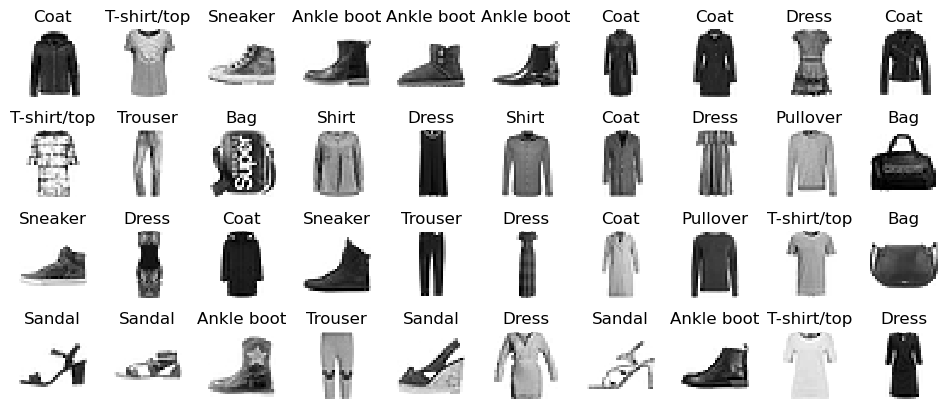

In [16]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_cols*1.2,n_rows*1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index=n_cols*row+col
        plt.subplot(n_rows,n_cols,index+1)
        plt.imshow(x_trn[index],cmap='binary',interpolation='nearest')
        plt.axis('off')
        plt.title(class_names[y_trn[index]],fontsize=12)
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

# plt.subplot(n_rows, n_cols, index + 1)
# Splits the figure into a 4×10 grid
# Activates the (index+1)th cell
# (Matplotlib indexing starts from 1, not 0)

# plt.imshow(x_trn[index], cmap='binary', interpolation='nearest')
# Displays the image at x_trn[index]
# cmap='binary' → black & white
# interpolation='nearest':
# Keeps pixels sharp
# No smoothing (important for MNIST)

# plt.axis('off')
# Hides x/y axes for clean visualization

# plt.subplots_adjust(wspace=0.2, hspace=0.5)
# wspace → horizontal spacing
# hspace → vertical spacing
# Prevents titles from overlapping

In [17]:
from keras import layers

model = keras.Sequential()
model.add(layers.Flatten(input_shape=[28,28]))
model.add(layers.Dense(300, activation='relu'))
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

D:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
keras.backend.clear_session() #clear_session() resets Keras so you start with a clean slate.
# Frees memory (RAM / GPU) used by old models
# Resets the computational graph
# Prevents layer name conflicts when you re-run code
# Useful in Jupyter / repeated experiments

np.random.seed(42)
tf.random.set_seed(42)

In [19]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [25]:
model.get_layer(hidden1.name) is hidden1

True

In [26]:
weights, biases = hidden1.get_weights()

In [27]:
weights

array([[-0.02161977, -0.00201777, -0.0004173 , ..., -0.02937569,
         0.00069073, -0.07433408],
       [ 0.07385638,  0.00321784, -0.07383071, ..., -0.01737948,
         0.0002622 , -0.06355177],
       [-0.03609925, -0.04321005, -0.06343269, ..., -0.06664181,
        -0.02916277, -0.04124379],
       ...,
       [-0.04067354,  0.00871333,  0.06067055, ..., -0.05367606,
         0.03940395, -0.03154257],
       [ 0.03912573,  0.06082669,  0.06996384, ...,  0.06126139,
        -0.03514302,  0.05401044],
       [ 0.02925919,  0.01082181,  0.05762093, ..., -0.06918544,
         0.03127813, -0.01534275]], dtype=float32)

In [28]:
weights.shape

(784, 300)

In [29]:
biases.shape

(300,)

In [31]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [32]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

This is equivalent to:



```python
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer=keras.optimizers.SGD(),
              metrics=[keras.metrics.sparse_categorical_accuracy])
```

In [34]:
history = model.fit(x_trn, y_trn, epochs=30,
                    validation_data=(x_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8301 - loss: 0.4868 - val_accuracy: 0.8462 - val_loss: 0.4574
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8450 - loss: 0.4422 - val_accuracy: 0.8574 - val_loss: 0.4243
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8547 - loss: 0.4151 - val_accuracy: 0.8624 - val_loss: 0.4034
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8616 - loss: 0.3952 - val_accuracy: 0.8668 - val_loss: 0.3870
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8665 - loss: 0.3791 - val_accuracy: 0.8702 - val_loss: 0.3742
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8709 - loss: 0.3654 - val_accuracy: 0.8712 - val_loss: 0.3637
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8743 - loss: 0.3536 - val_accuracy: 0.8744 - val_loss: 0.3563
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8778 - loss: 0.3430 - 

In [35]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [36]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

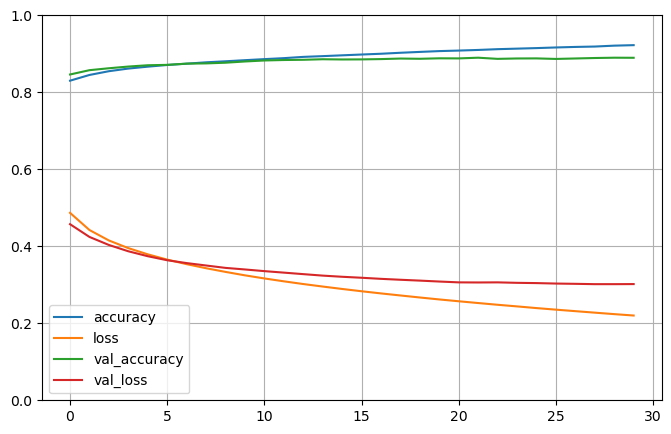

In [39]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [40]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8766 - loss: 0.3458 


[0.3458015024662018, 0.8766000270843506]

## TESTING

In [43]:
X_new = x_test[:3]

**This is how the test data looks like**

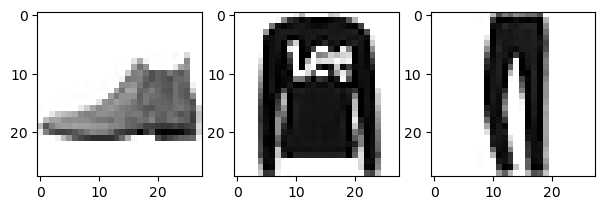

In [45]:
plt.figure(figsize=(7.2, 2.4))
for index,image in enumerate(X_new):
    plt.subplot(1,3,index+1)
    plt.imshow(image,cmap='binary',interpolation='nearest')
plt.show()

In [46]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


array([9, 2, 1])

In [53]:
print(np.array(class_names)[y_pred])


['Ankle boot' 'Pullover' 'Trouser']


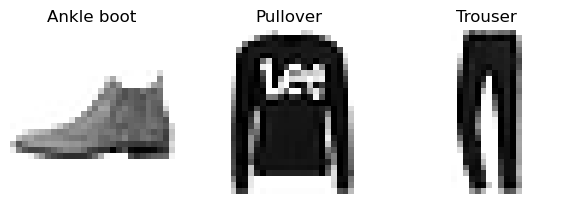

In [56]:
plt.figure(figsize=(7.2, 2.4))
for index,image in enumerate(X_new):
    plt.subplot(1,3,index+1)
    plt.imshow(image,cmap='binary',interpolation='nearest')
    plt.axis('off')
    plt.title(class_names[y_pred[index]],fontsize=12)
plt.show()

In [58]:
y_new = y_test[:3]
y_new
print(np.array(class_names)[y_new])


['Ankle boot' 'Pullover' 'Trouser']
